In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
set_seed

<function __main__.set_seed(seed=42)>

In [5]:
epochs = 20
loss_history = []

In [6]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [8]:
import torch_geometric
from torch_geometric.data import Data

print("PyG OK")

p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG OK


In [9]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset, get_graph_dataloader, build_node_vocab, build_rel_vocab

In [10]:
import pandas as pd

In [11]:
df_train = pd.read_csv("../data/df_train.csv")
df_val = pd.read_csv("../data/df_val.csv")

all_labels = df_train["labels"].unique()

label2idx = {l: i for i, l in enumerate(all_labels)}
idx2label = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"] = df_val["labels"].map(label2idx)

node_vocab = build_node_vocab(df_train)
rel_vocab = build_rel_vocab(df_train)

In [12]:
train_dataset = GQAGraphDataset(
    df=df_train,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

val_dataset = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

NUM_CLASSES = len(label2idx)

train_loader = get_graph_dataloader(
    train_dataset,
    n_classes=NUM_CLASSES,
    n_samples=4,
)

In [13]:
from src.models.gnn import GINEEmbeddingNet

In [14]:
model = GINEEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    edge_vocab_size=len(rel_vocab),
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
)

In [15]:
from src.training.contrastiveloss import supervised_contrastive_loss_GNN
from src.training.train_model import train_graph_model

In [17]:
ckpt_dir = os.path.join(os.path.abspath(".."), "experiments", "checkpoints")
resume_from = None #os.path.join(ckpt_dir, "gnn10.pth")
resume_epoch = None  # solo se il .pth vecchio ha solo i pesi: es. 11 per continuare da epoca 11

model, history = train_graph_model(
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    model=model,
    loader=train_loader,
    loss_fn=lambda emb, labels: supervised_contrastive_loss_GNN(emb, labels, temperature=0.07),
    device=device,
    epochs=epochs,
    lr=3e-4,
    weight_decay=1e-4,
    checkpoint_path=resume_from,
    resume_epoch=resume_epoch,
    save_path=os.path.join(ckpt_dir, f"gnn{epochs}.pth"),
)

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 1/20 - loss: 3.7813 - lr: 2.98e-04
Epoch 2/20 - loss: 3.4873 - lr: 2.93e-04
Epoch 3/20 - loss: 3.3261 - lr: 2.84e-04
Epoch 4/20 - loss: 3.2192 - lr: 2.73e-04
Epoch 5/20 - loss: 3.0996 - lr: 2.58e-04
Epoch 6/20 - loss: 3.0027 - lr: 2.41e-04
Epoch 7/20 - loss: 2.8571 - lr: 2.22e-04
Epoch 8/20 - loss: 2.7679 - lr: 2.02e-04
Epoch 9/20 - loss: 2.6889 - lr: 1.80e-04
Epoch 10/20 - loss: 2.5819 - lr: 1.58e-04
Epoch 11/20 - loss: 2.5055 - lr: 1.35e-04
Epoch 12/20 - loss: 2.4567 - lr: 1.13e-04
Epoch 13/20 - loss: 2.3838 - lr: 9.28e-05
Epoch 14/20 - loss: 2.3139 - lr: 7.37e-05
Epoch 15/20 - loss: 2.2840 - lr: 5.67e-05
Epoch 16/20 - loss: 2.2275 - lr: 4.22e-05
Epoch 17/20 - loss: 2.1840 - lr: 3.05e-05
Epoch 18/20 - loss: 2.1778 - lr: 2.20e-05
Epoch 19/20 - loss: 2.1628 - lr: 1.68e-05
Epoch 20/20 - loss: 2.1261 - lr: 1.50e-05
Checkpoint saved to: p:\Uni\mujoco\dl26-projects\experiments\checkpoints\gnn20.pth


In [18]:
print(history)

[3.781272901858475, 3.4873065199340667, 3.326119164278977, 3.219245533098901, 3.0996274074116847, 3.002653353232101, 2.8571421559017494, 2.7679202146363675, 2.688905192134981, 2.5818868471202707, 2.505520083957777, 2.456748814951452, 2.383755263544972, 2.313878333182109, 2.2839658967871914, 2.22754068802717, 2.184044027863595, 2.177764442198889, 2.1627831652277427, 2.1260530663250092]


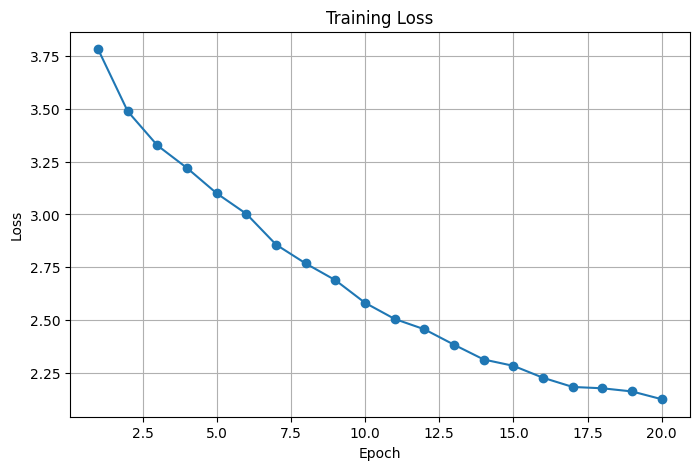

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [20]:
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
gnne_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    edge_vocab_size=len(rel_vocab),
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
).to(device)

parent_dir = os.path.abspath("..")
ckpt_path = os.path.join(
    parent_dir,
    "experiments",
    "checkpoints",
    f"gnn{epochs}.pth",
)

from src.training.train_model import load_model_weights

load_model_weights(ckpt_path, gnne_model, device)
gnne_model.eval()

GINEEmbeddingNet(
  (node_emb): Embedding(1638, 64, padding_idx=0)
  (node_encoder): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (edge_encoder): Embedding(308, 256)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (projector): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [21]:
from src.evaluation.retrieval import (
    compute_graph_embeddings,
    evaluate_retrieval,
    print_metrics,
    plot_graph_retrieval,
    plot_tsne,
)

In [22]:
embeddings, labels = compute_graph_embeddings(
    model=gnne_model,
    dataset=val_dataset,
    device=device,
    batch_size=64,
    num_workers=0,
    normalize=True,
)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)


results, indices, scores = evaluate_retrieval(
    embeddings,
    labels,
    ks=(1, 5, 10),
)


print_metrics(results)

Embeddings shape: torch.Size([3208, 128])
Labels shape: torch.Size([3208])

========== Retrieval Metrics ==========

acc@1               : 0.4991
precision_macro     : 0.4877
recall_macro        : 0.4892
recall@1            : 0.4991
recall@5            : 0.7883
recall@10           : 0.8572
precision@1         : 0.4991
precision@5         : 0.5002
precision@10        : 0.4978
mrr                 : 0.6210
map                 : 0.5778



[1250 2366  158  503  593]


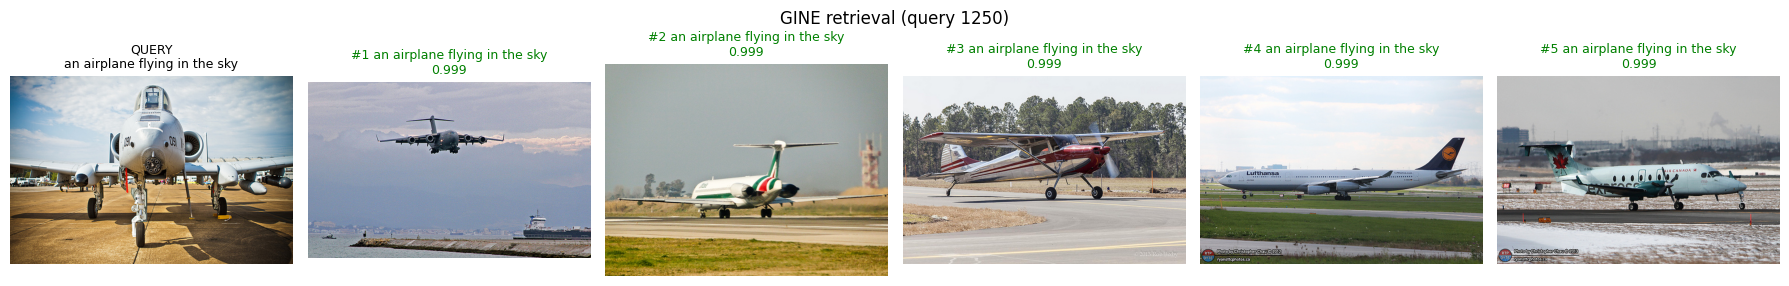


Query 1250: an airplane flying in the sky
#1 idx=876 score=0.999 an airplane flying in the sky [OK]
#2 idx=2424 score=0.999 an airplane flying in the sky [OK]
#3 idx=343 score=0.999 an airplane flying in the sky [OK]
#4 idx=246 score=0.999 an airplane flying in the sky [OK]
#5 idx=2090 score=0.999 an airplane flying in the sky [OK]


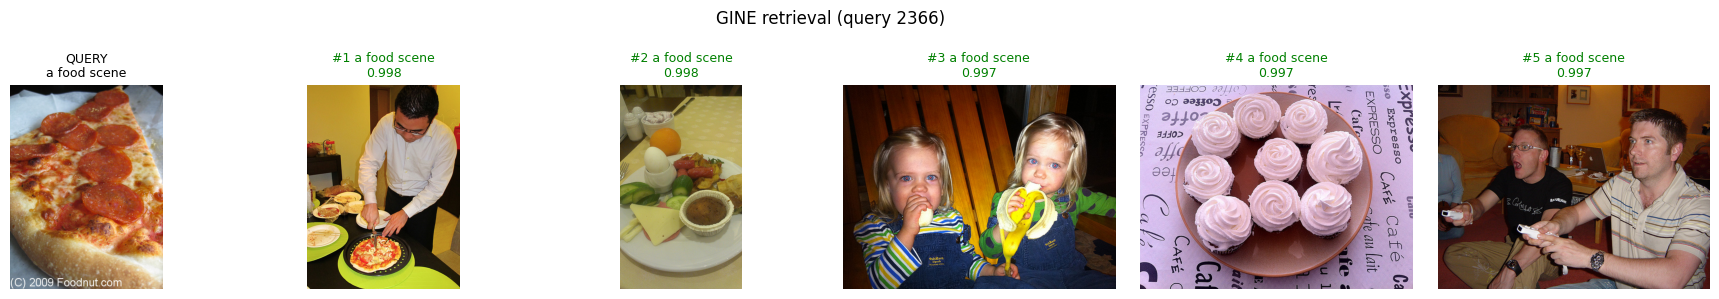


Query 2366: a food scene
#1 idx=3204 score=0.998 a food scene [OK]
#2 idx=1710 score=0.998 a food scene [OK]
#3 idx=1707 score=0.997 a food scene [OK]
#4 idx=3181 score=0.997 a food scene [OK]
#5 idx=482 score=0.997 a food scene [OK]


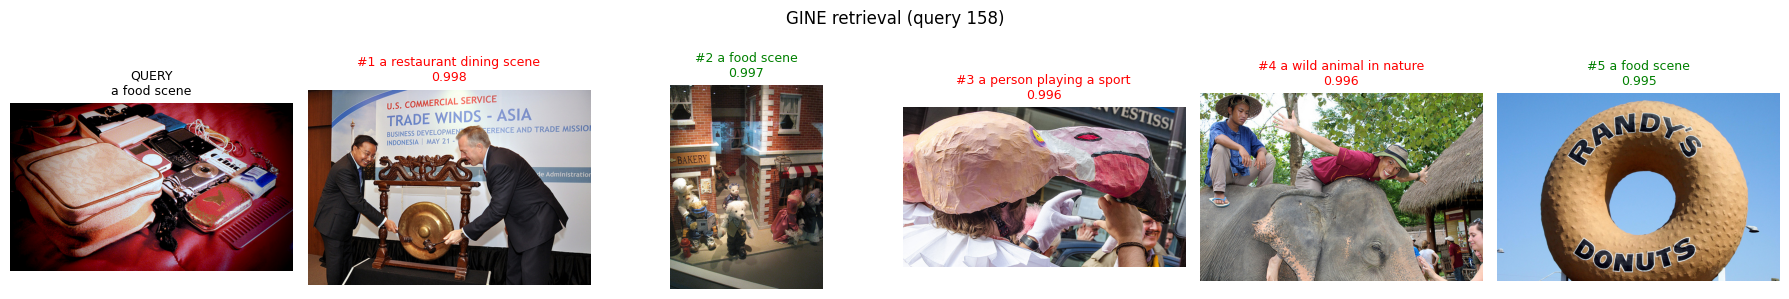


Query 158: a food scene
#1 idx=285 score=0.998 a restaurant dining scene [MISS]
#2 idx=2302 score=0.997 a food scene [OK]
#3 idx=2385 score=0.996 a person playing a sport [MISS]
#4 idx=1248 score=0.996 a wild animal in nature [MISS]
#5 idx=1495 score=0.995 a food scene [OK]


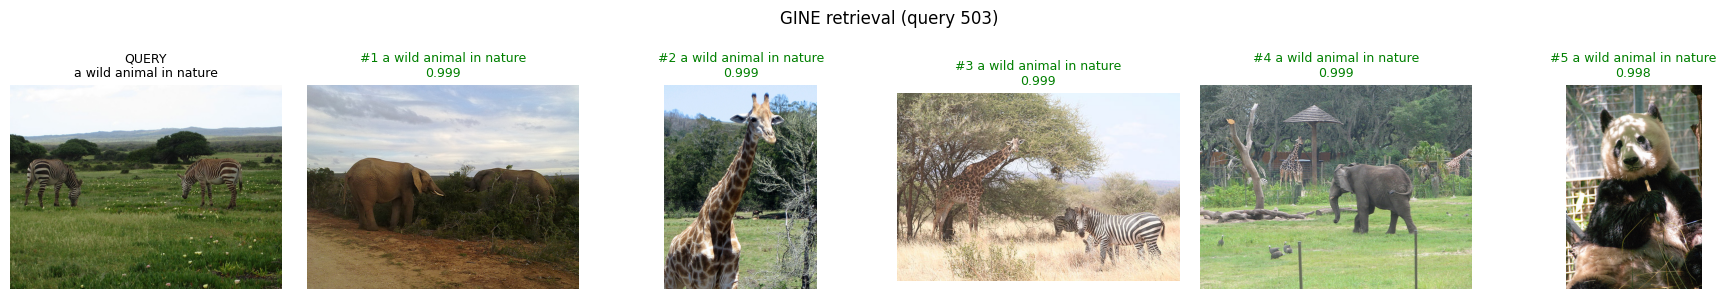


Query 503: a wild animal in nature
#1 idx=2001 score=0.999 a wild animal in nature [OK]
#2 idx=1855 score=0.999 a wild animal in nature [OK]
#3 idx=2629 score=0.999 a wild animal in nature [OK]
#4 idx=754 score=0.999 a wild animal in nature [OK]
#5 idx=737 score=0.998 a wild animal in nature [OK]


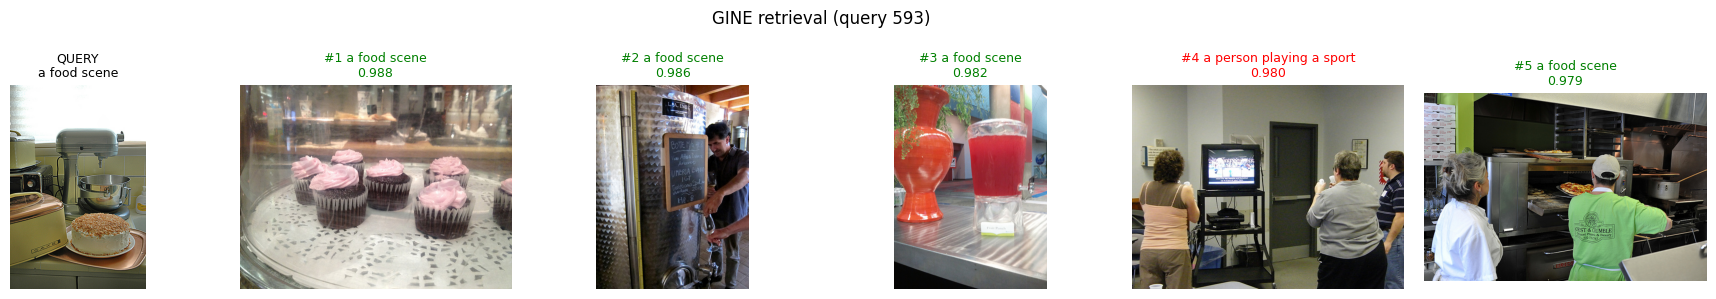


Query 593: a food scene
#1 idx=2987 score=0.988 a food scene [OK]
#2 idx=1075 score=0.986 a food scene [OK]
#3 idx=3080 score=0.982 a food scene [OK]
#4 idx=787 score=0.980 a person playing a sport [MISS]
#5 idx=2593 score=0.979 a food scene [OK]


In [23]:
IMAGE_DIR = os.path.join(os.path.abspath(".."), "data", "images")

np.random.seed(40)
query_indices = np.random.choice(len(labels), size=5, replace=False)

print(query_indices)
for query_idx in query_indices:


    plot_graph_retrieval(
        df=val_dataset,
        image_dir=IMAGE_DIR,
        labels=labels,
        indices=indices,
        scores=scores,
        query_idx=query_idx,
        idx2label=val_dataset.idx2label,
        topk=5,
        title=f"GINE retrieval (query {query_idx})",
    )

    q_label = labels[query_idx].item()
    print(f"\nQuery {query_idx}: {val_dataset.idx2label.get(q_label, q_label)}")

    for rank, (idx, score) in enumerate(
        zip(indices[query_idx][1:6], scores[query_idx][1:6]),
        start=1
    ):
        lbl = int(labels[idx])
        mark = "OK" if lbl == q_label else "MISS"

        print(
            f"#{rank} idx={idx} score={score:.3f} "
            f"{val_dataset.idx2label.get(lbl, lbl)} [{mark}]"
        )

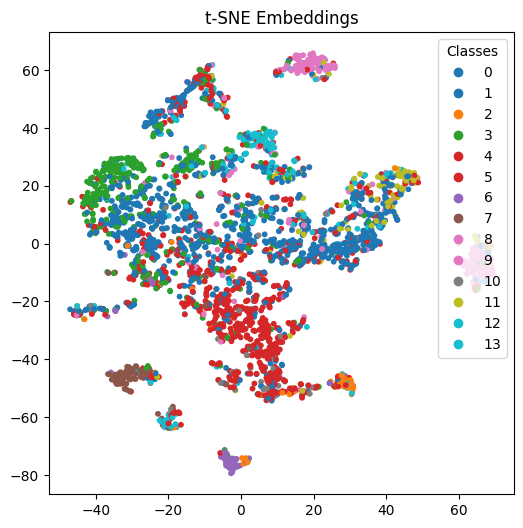

In [24]:
plot_tsne(
    embeddings=embeddings,
    labels=labels
          )